In [2]:
import pandas as pd
import numpy as np

gdp = pd.read_csv("./Clean Data/gdp_per_capita.csv")
health_exp = pd.read_csv("./Clean Data/health_expenditure.csv")
health_spend = pd.read_csv("./Clean Data/health_spending.csv")
doctors = pd.read_csv("./Clean Data/doctors_per_capita.csv")

df = gdp.merge(health_exp, on=["country", "year"], how="inner")
df = df.merge(health_spend, on=["country", "year"], how="inner")
df = df.merge(doctors, on=["country", "year"], how="inner")

df.to_csv("merged_dataset.csv", index=False)

df.head()

,country,year,gdp_per_capita,health_expenditure,health_spending,doctors_per_capita
0,Austria,2020,48716.409890,11.412930,11.413,11.06
1,Austria,2021,53648.643798,12.185215,12.185,11.41
2,Austria,2022,52336.772522,11.225198,11.225,11.18
3,Austria,2023,56579.504175,11.152973,11.153,11.29
4,Belgium,2020,45906.287581,11.462530,11.463,13.08


In [3]:
import numpy as np
import pandas as pd

In [4]:
df.shape

(98, 6)

In [5]:
df.isnull().sum()

country               0
year                  0
gdp_per_capita        0
health_expenditure    0
health_spending       0
doctors_per_capita    0
dtype: int64

In [6]:
df["country"].nunique()

25

In [7]:
df["year"].nunique()

4

In [8]:
df[["gdp_per_capita", "doctors_per_capita"]].corr()

,gdp_per_capita,doctors_per_capita
gdp_per_capita,1.00000,0.77579
doctors_per_capita,0.77579,1.00000


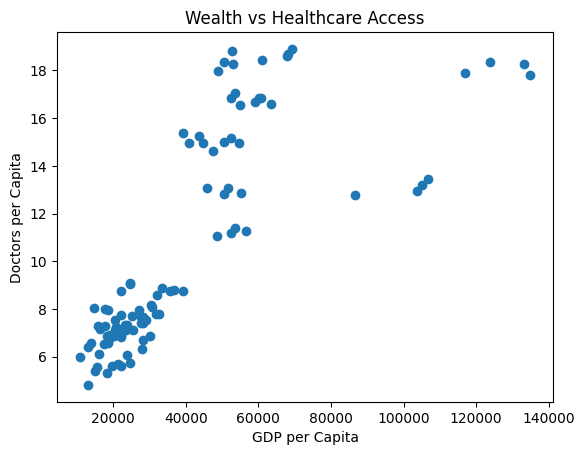

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import os
os.makedirs("results/figures", exist_ok=True)

plt.scatter(df["gdp_per_capita"], df["doctors_per_capita"])
plt.xlabel("GDP per Capita")
plt.ylabel("Doctors per Capita")
plt.title("Wealth vs Healthcare Access")
plt.show()

plt.savefig("results/figures/figure1.png", bbox_inches="tight")
plt.show()

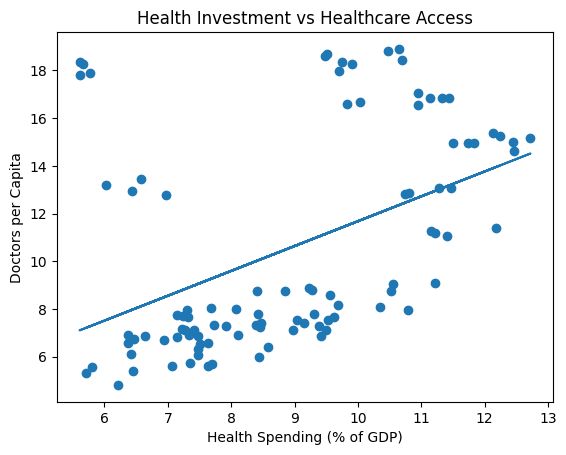

<Figure size 640x480 with 0 Axes>

In [11]:
z = np.polyfit(df["health_spending"], df["doctors_per_capita"], 1)
p = np.poly1d(z)

plt.scatter(df["health_spending"], df["doctors_per_capita"])
plt.plot(df["health_spending"], p(df["health_spending"]))
plt.xlabel("Health Spending (% of GDP)")
plt.ylabel("Doctors per Capita")
plt.title("Health Investment vs Healthcare Access")
plt.show()

plt.savefig("results/figures/figure2.png", bbox_inches="tight")
plt.show()

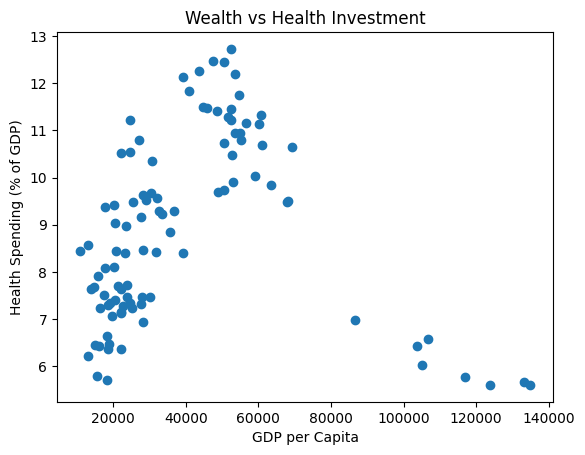

<Figure size 640x480 with 0 Axes>

In [15]:
plt.scatter(df["gdp_per_capita"], df["health_spending"])
plt.xlabel("GDP per Capita")
plt.ylabel("Health Spending (% of GDP)")
plt.title("Wealth vs Health Investment")
plt.show()

df[["gdp_per_capita", "health_spending"]].corr()

plt.savefig("results/figures/figure3.png", bbox_inches="tight")
plt.show()

In [13]:
df.sort_values(by="doctors_per_capita", ascending=False).head()
df.sort_values(by="gdp_per_capita", ascending=False).head()

,country,year,gdp_per_capita,health_expenditure,health_spending,doctors_per_capita
65,Luxembourg,2021,134965.815442,5.608061,5.608,17.79
67,Luxembourg,2023,133230.619179,5.787780,5.668,18.27
66,Luxembourg,2022,123719.658916,5.609269,5.609,18.37
64,Luxembourg,2020,116860.028172,5.767118,5.767,17.91
55,Ireland,2023,106818.917131,6.575385,6.575,13.46


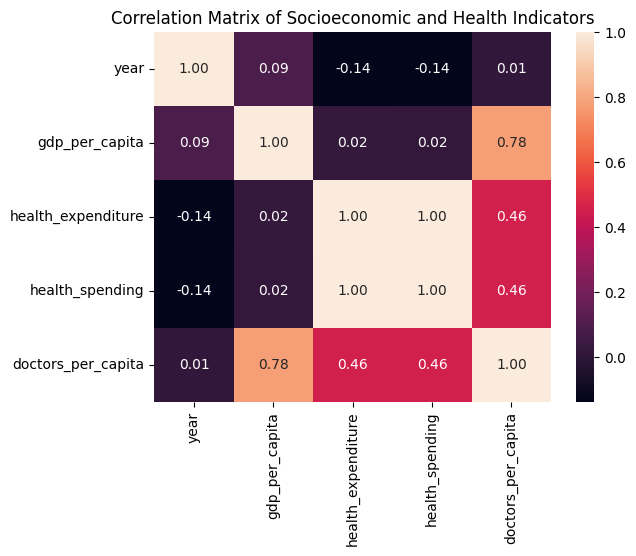

In [18]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix of Socioeconomic and Health Indicators")

plt.savefig("results/figures/figure4.png", bbox_inches="tight")
plt.show()